# Week 4-5 — Feature EDA (Part 2)

With the feature matrix extracted in notebook 02, we now dig deeper:
- **Correlation analysis** — which features are redundant?
- **Feature variance** — which features vary most across emotions?
- **Discriminability** — ANOVA F-statistic to rank features by class separability
- **Pairwise scatter plots** of top features
- **Waveform gallery** — one sample per emotion for intuition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy import stats

sns.set_theme(style='whitegrid')
EMOTION_ORDER = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

## 1. Load Features

In [2]:
df      = pd.read_csv('../outputs/features.csv')
meta    = pd.read_csv('../outputs/metadata.csv')

LABEL_COLS   = ['filename','emotion','emotion_id','actor','gender','channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X = df[feature_cols].values
y = df['emotion'].values

print(f'Feature matrix: {X.shape}   ({len(feature_cols)} features, {len(np.unique(y))} classes)')

Feature matrix: (2452, 194)   (194 features, 8 classes)


## 2. Correlation Heatmap

High correlation between features indicates redundancy — PCA or feature selection could help.

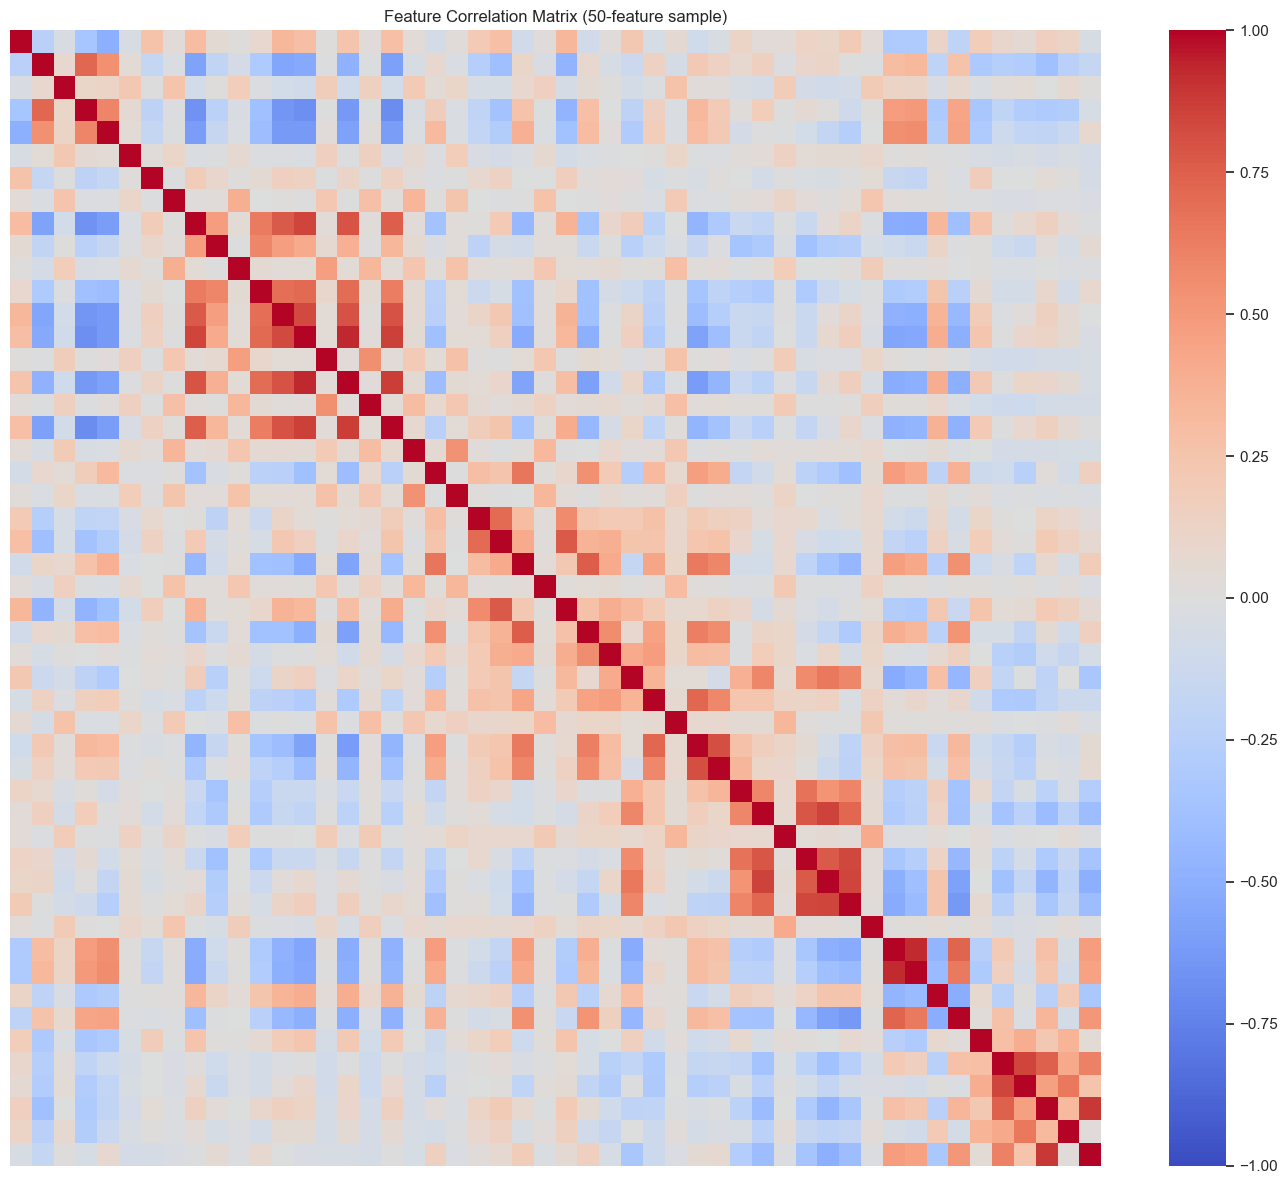

Saved to outputs/feature_correlation.png
Feature pairs with |r| > 0.9: 29 / 18721 (0.2%)


In [3]:
# Use a random 50-feature subset for readability
rng        = np.random.default_rng(42)
sub_idx    = rng.choice(len(feature_cols), 50, replace=False)
sub_cols   = [feature_cols[i] for i in sorted(sub_idx)]
corr       = df[sub_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False,
            vmin=-1, vmax=1, linewidths=0)
ax.set_title('Feature Correlation Matrix (50-feature sample)')
plt.tight_layout()
plt.savefig('../outputs/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/feature_correlation.png')

# Fraction of highly correlated pairs
full_corr  = df[feature_cols].corr().values
mask       = np.triu(np.ones_like(full_corr, dtype=bool), k=1)
upper      = full_corr[mask]
high_corr  = np.sum(np.abs(upper) > 0.9)
print(f'Feature pairs with |r| > 0.9: {high_corr} / {len(upper)} ({100*high_corr/len(upper):.1f}%)')

## 3. Feature Discriminability — One-Way ANOVA

For each feature we run a one-way ANOVA across the 8 emotion classes.  A high F-statistic
means the feature's mean differs significantly between classes — it's more useful for classification.

In [4]:
f_stats = []
for col in feature_cols:
    groups = [df.loc[df['emotion'] == em, col].values for em in EMOTION_ORDER]
    f, p   = stats.f_oneway(*groups)
    f_stats.append({'feature': col, 'F': f, 'p': p})

fdf = pd.DataFrame(f_stats).sort_values('F', ascending=False).reset_index(drop=True)
print('Top 20 most discriminative features (by ANOVA F-statistic):')
print(fdf.head(20).to_string(index=False))

Top 20 most discriminative features (by ANOVA F-statistic):
             feature          F             p
        mfcc_01_mean 203.274845 4.098197e-238
             rms_std 178.003812 2.345594e-213
            rms_mean 175.341027 1.114246e-210
        dmfcc_01_std 128.461035 3.186180e-161
        mfcc_03_mean  87.134927 1.627964e-113
         mfcc_01_std  78.278569 1.004762e-102
         mfcc_03_std  76.048171 5.663700e-100
         mfcc_31_std  74.370854  6.776008e-98
        dmfcc_03_std  64.109094  5.181999e-85
         mfcc_40_std  58.933391  2.118092e-78
        dmfcc_06_std  57.124497  4.516530e-76
spectral_rolloff_std  56.526832  2.668991e-75
        dmfcc_40_std  55.985032  1.338645e-74
         mfcc_32_std  54.775702  4.930440e-73
        dmfcc_04_std  50.505712  1.807102e-67
        dmfcc_02_std  50.384694  2.602859e-67
         mfcc_39_std  49.544188  3.290258e-66
         mfcc_04_std  47.191096  4.099310e-63
         mfcc_02_std  46.839128  1.194279e-62
        dmfcc_39_std

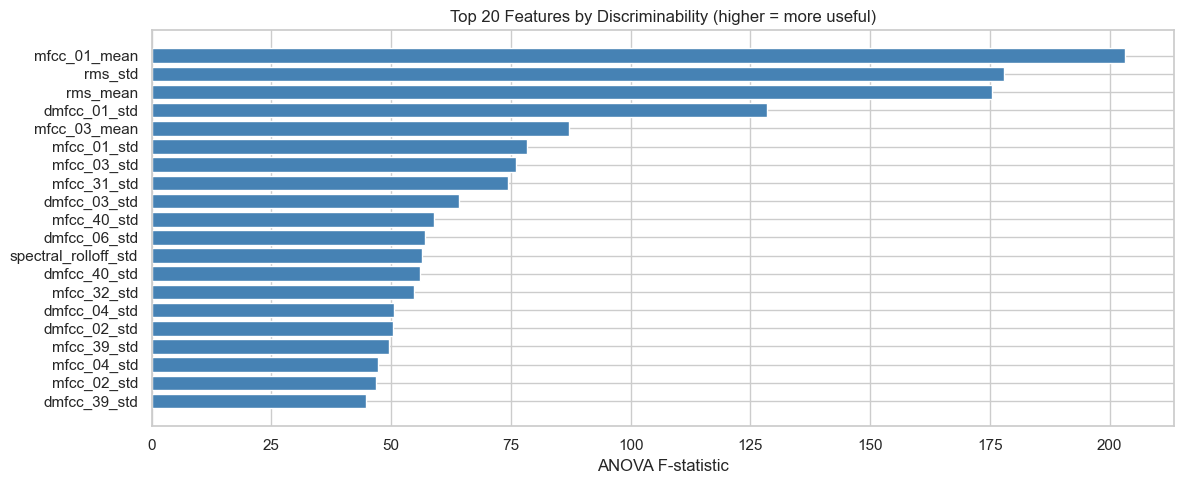

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
top20   = fdf.head(20)
ax.barh(top20['feature'][::-1], top20['F'][::-1], color='steelblue')
ax.set_xlabel('ANOVA F-statistic')
ax.set_title('Top 20 Features by Discriminability (higher = more useful)')
plt.tight_layout()
plt.savefig('../outputs/feature_discriminability.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Top Feature Distributions by Emotion

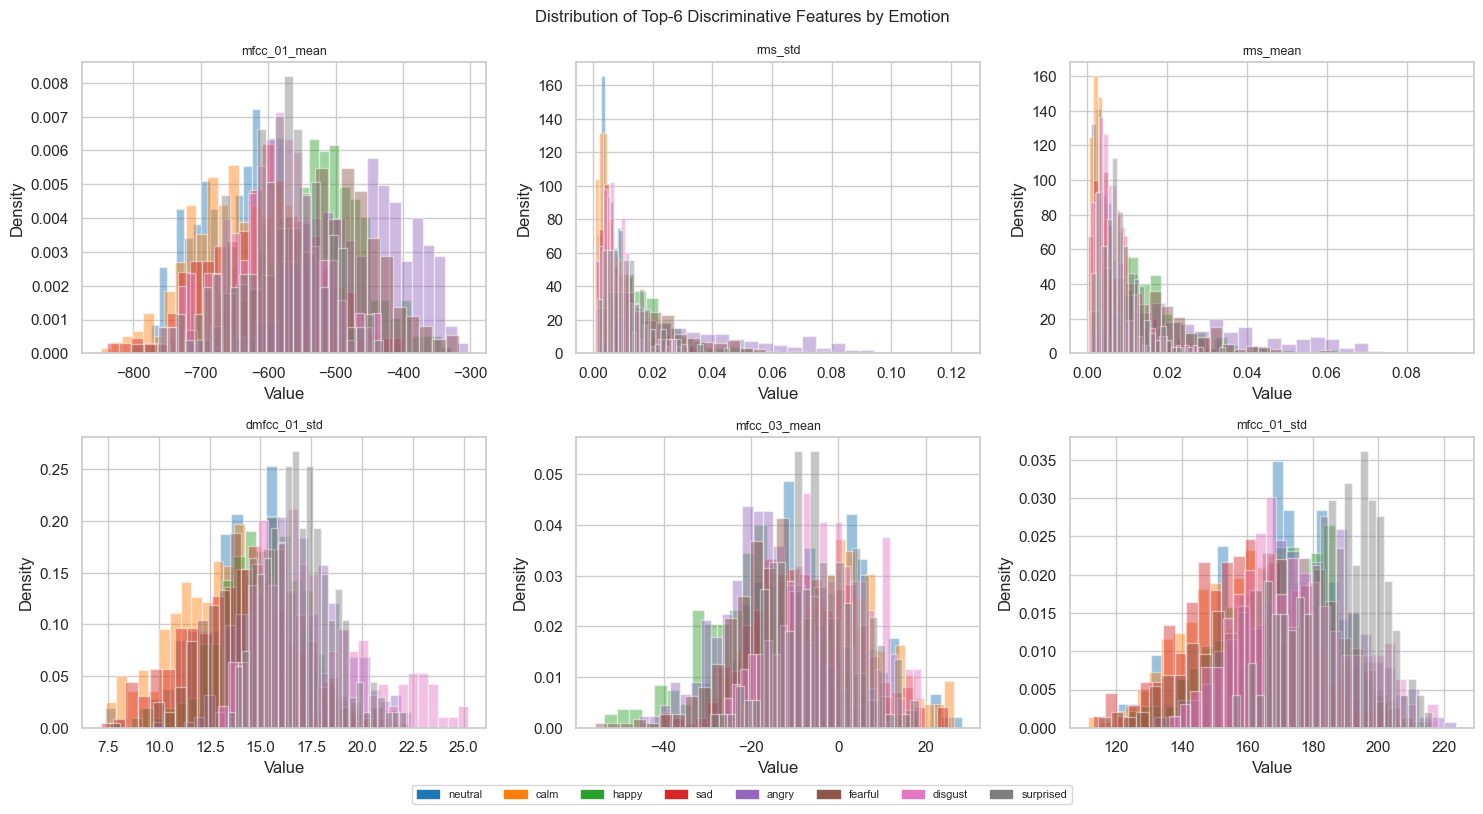

In [6]:
top6    = fdf.head(6)['feature'].tolist()
palette = dict(zip(EMOTION_ORDER, sns.color_palette('tab10', 8)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), top6):
    for em in EMOTION_ORDER:
        vals = df.loc[df['emotion'] == em, feat].values
        ax.hist(vals, bins=25, alpha=0.45, label=em, color=palette[em], density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

handles = [plt.Rectangle((0,0),1,1, color=palette[em]) for em in EMOTION_ORDER]
fig.legend(handles, EMOTION_ORDER, loc='lower center', ncol=8, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Distribution of Top-6 Discriminative Features by Emotion', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/top_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Waveform Gallery — One Sample per Emotion

Listening to the data: raw waveforms give intuition for how emotions differ acoustically.

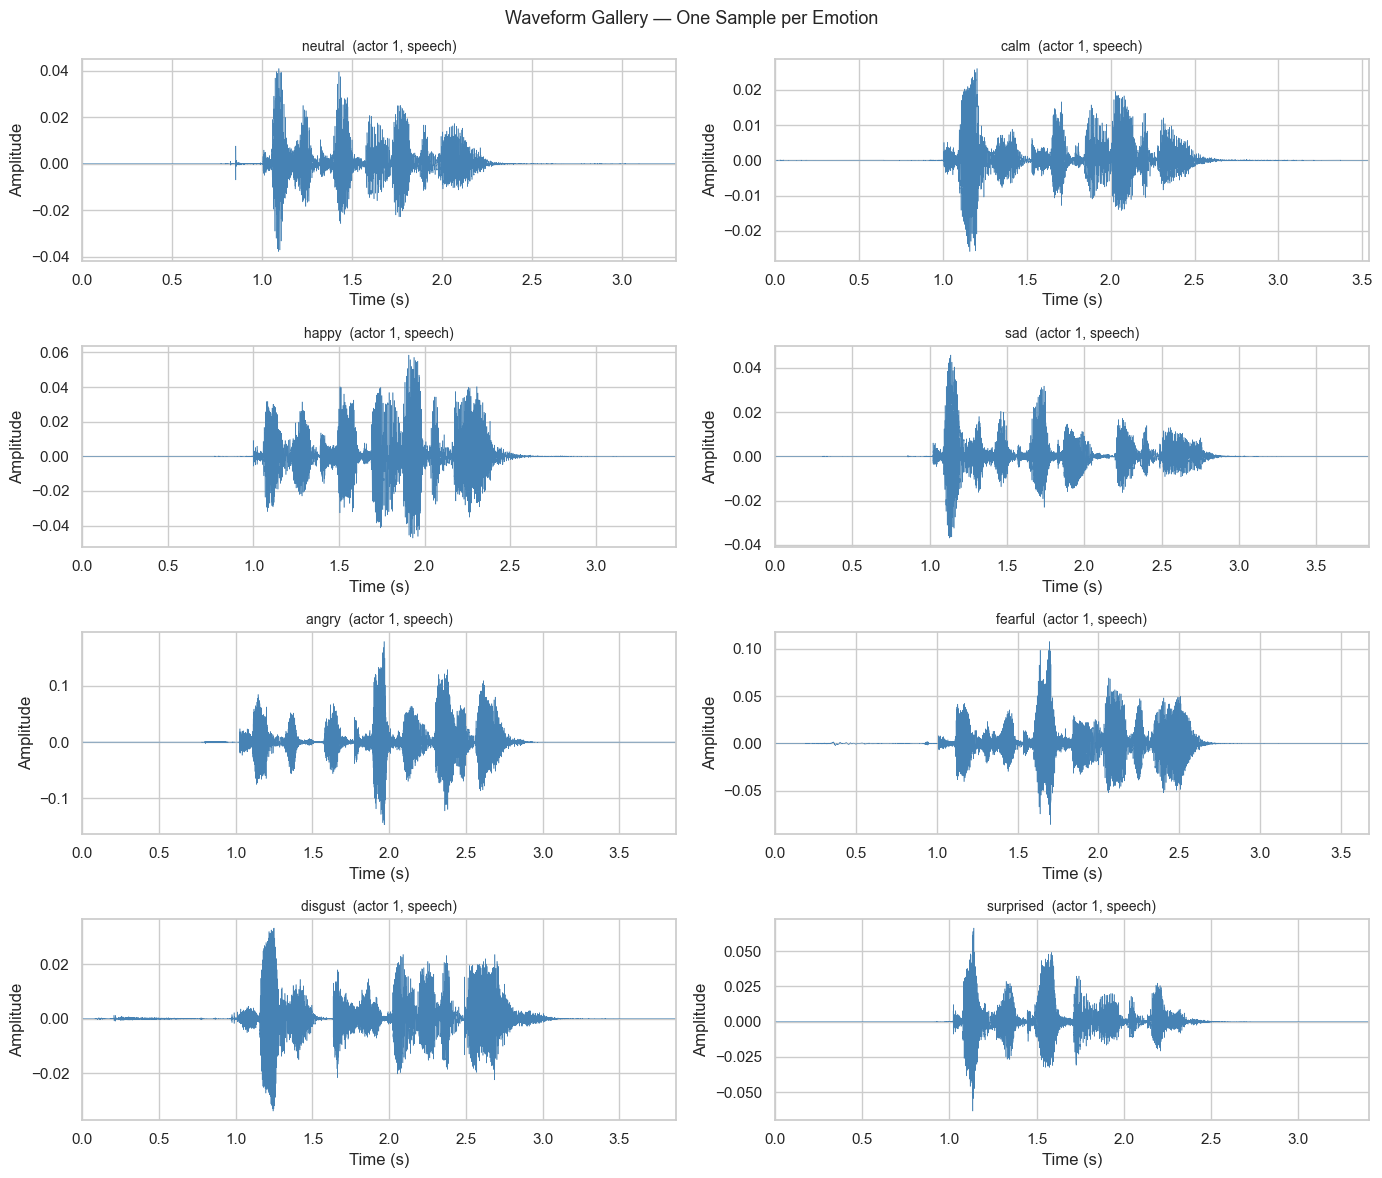

Saved to outputs/waveform_gallery.png


In [7]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for ax, em in zip(axes.flatten(), EMOTION_ORDER):
    row   = meta[meta['emotion'] == em].iloc[0]
    y_sig, sr = librosa.load(row['filepath'], sr=22050)
    t = np.linspace(0, len(y_sig)/sr, len(y_sig))
    ax.plot(t, y_sig, linewidth=0.4, color='steelblue')
    ax.set_title(f'{em}  (actor {row["actor"]}, {row["channel"]})', fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, t[-1])

plt.suptitle('Waveform Gallery — One Sample per Emotion', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/waveform_gallery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/waveform_gallery.png')

## 6. Feature Summary Statistics

In [8]:
feat_summary = pd.DataFrame({
    'Feature group': ['MFCCs (mean+std)', 'Delta MFCCs (mean+std)', 'Chroma (mean+std)',
                      'ZCR', 'RMS energy', 'Spectral centroid', 'Spectral bandwidth', 'Spectral rolloff'],
    'Num features':  [80, 80, 24, 2, 2, 2, 2, 2],
    'Top F-stat':    [
        fdf[fdf['feature'].str.startswith('mfcc_')]['F'].max(),
        fdf[fdf['feature'].str.startswith('dmfcc_')]['F'].max(),
        fdf[fdf['feature'].str.startswith('chroma_')]['F'].max(),
        fdf[fdf['feature'].str.startswith('zcr_')]['F'].max(),
        fdf[fdf['feature'].str.startswith('rms_')]['F'].max(),
        fdf[fdf['feature'].str.startswith('spectral_centroid')]['F'].max(),
        fdf[fdf['feature'].str.startswith('spectral_bandwidth')]['F'].max(),
        fdf[fdf['feature'].str.startswith('spectral_rolloff')]['F'].max(),
    ]
})
feat_summary['Top F-stat'] = feat_summary['Top F-stat'].round(1)
print(feat_summary.to_string(index=False))
feat_summary

         Feature group  Num features  Top F-stat
      MFCCs (mean+std)            80       203.3
Delta MFCCs (mean+std)            80       128.5
     Chroma (mean+std)            24        41.3
                   ZCR             2        13.1
            RMS energy             2       178.0
     Spectral centroid             2        23.2
    Spectral bandwidth             2        21.6
      Spectral rolloff             2        56.5


,Feature group,Num features,Top F-stat
0,MFCCs (mean+std),80,203.3
1,Delta MFCCs (mean+std),80,128.5
2,Chroma (mean+std),24,41.3
3,ZCR,2,13.1
4,RMS energy,2,178.0
5,Spectral centroid,2,23.2
6,Spectral bandwidth,2,21.6
7,Spectral rolloff,2,56.5
